# LIBRARY

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree
import json
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from collections import Counter
from imblearn.over_sampling import SMOTE

In [ ]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

In [3]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8382, 17)
y shape : (8382,)
Classes : [0. 1. 2. 3.]
Class counts : {0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85}


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [5]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Cascade Model

## model

In [ ]:
def train_one_step_rf(X_train, y_binary, X_test, y_test_binary, step_name,
                      n_iter=30, n_splits=5, random_state=0):

    print(f"\n{'='*60}")
    print(f"  STEP: {step_name}")
    print(f"  Training samples : {len(y_binary)}")
    print(f"  Positive class   : {y_binary.sum()} samples")
    print(f"  Negative class   : {(y_binary==0).sum()} samples")
    print(f"{'='*60}")

    param_list = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 5],
        'max_features': ['log2'],
        'class_weight': ['balanced'],
        'criterion': ['gini']
    }

    random_search = RandomizedSearchCV(
        RandomForestClassifier(random_state=random_state),
        param_distributions=param_list,
        cv=KFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring='f1_macro',
        n_jobs=-1,
        refit=True,
        n_iter=n_iter,
        random_state=random_state
    )

    random_search.fit(X_train, y_binary)
    best_model = random_search.best_estimator_

    print(f"\n  Best params : {random_search.best_params_}")
    print(f"  Best CV F1  : {random_search.best_score_:.4f}")

    y_pred_binary = best_model.predict(X_test)
    y_proba       = best_model.predict_proba(X_test)[:, 1]

    test_f1 = f1_score(y_test_binary, y_pred_binary, average='weighted')
    print(f"  Test F1     : {test_f1:.4f}")

    cm = confusion_matrix(y_test_binary, y_pred_binary)
    disp = ConfusionMatrixDisplay(cm, display_labels=[f'not {step_name}', step_name])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {step_name}')
    plt.show()


    print(classification_report(y_test_binary, y_pred_binary,
                                target_names=[f'not {step_name}', step_name]))

    return best_model


In [ ]:
def print_dist(y, title='', binary=False):

    print(f"\n--- {title} ---")
    counts = Counter(y)

    if binary:
        print(f"0 → {counts.get(0, 0)} samples")
        print(f"1 → {counts.get(1, 0)} samples")
    else:
        for cls in sorted(counts.keys()):
            print(f"Class {cls}: {counts[cls]} samples")

    print(f"Total: {len(y)} samples")


In [49]:
step_results = {}   
y_pred_final = np.full(len(X_test), -1)
original_idx = np.arange(len(X_test))

# Working copies that shrink at each cascade step
X_tr = X_train.copy()
y_tr = y_train.copy()
X_te = X_test.copy()
y_te = y_test.copy()

models  = {}
classes = np.unique(y_train)

print(f"Classes found  : {classes}")
print(f"Train samples  : {len(y_tr)}")
print(f"Test samples   : {len(y_te)}")

Classes found  : [0. 1. 2. 3.]
Train samples  : 5867
Test samples   : 2515


In [50]:
print_dist(y_tr, 'TRAIN')
print_dist(y_te, 'TEST')


--- TRAIN ---
Class 0.0: 4056 samples
Class 1.0: 1097 samples
Class 2.0: 655 samples
Class 3.0: 59 samples
Total: 5867 samples

--- TEST ---
Class 0.0: 1738 samples
Class 1.0: 470 samples
Class 2.0: 281 samples
Class 3.0: 26 samples
Total: 2515 samples


## Class 0


In [51]:
# STEP 1: sii=0 vs [1, 2, 3] 
y_binary_tr = (y_tr == 0).astype(int)
y_binary_te = (y_te == 0).astype(int)


In [52]:
print_dist(y_binary_tr, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


--- TRAIN — binary step 1 ---
0 → 1811 samples
1 → 4056 samples
Total: 5867 samples

--- TEST  — binary step 1 ---
0 → 777 samples
1 → 1738 samples
Total: 2515 samples


In [ ]:


over_dic={0:3500}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 4056, 0: 3500})


In [54]:
print_dist(y_res, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


--- TRAIN — binary step 1 ---
0 → 3500 samples
1 → 4056 samples
Total: 7556 samples

--- TEST  — binary step 1 ---
0 → 777 samples
1 → 1738 samples
Total: 2515 samples



  STEP: sii=0
  Training samples : 5867
  Positive class   : 4056 samples
  Negative class   : 1811 samples

  Best params : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 7, 'criterion': 'gini', 'class_weight': 'balanced'}
  Best CV F1  : 0.6140
  Test F1     : 0.6563


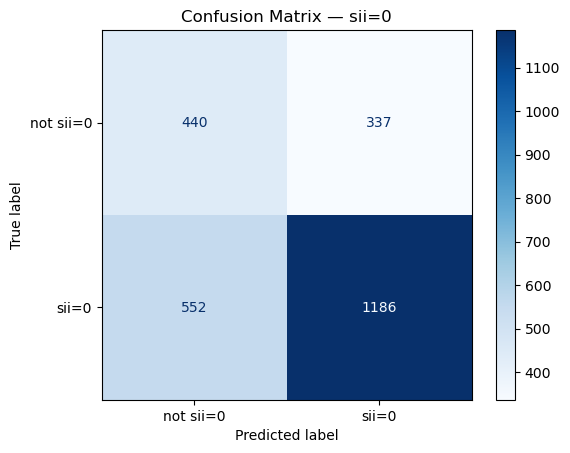

              precision    recall  f1-score   support

           0       0.44      0.57      0.50       777
           1       0.78      0.68      0.73      1738

    accuracy                           0.65      2515
   macro avg       0.61      0.62      0.61      2515
weighted avg       0.68      0.65      0.66      2515



In [55]:
models[0] = train_one_step_rf(X_tr, y_binary_tr, X_te, y_binary_te, step_name='sii=0')


In [56]:
# samples predicted as sii=0 → assign 0 to their original position
y_pred_te   = models[0].predict(X_test)

#----------------------------------
step_results[0] = {
    'step_name':    'sii=0 vs [1,2,3]',
    'y_true_bin':   y_binary_te.copy(),      # verdadero binario
    'y_pred_bin':   y_pred_te.copy(),        # predicho binario
    'y_true_orig':  y_test.copy(),             # verdadero multiclass en este paso
    'original_idx': original_idx.copy(),     # índices originales
}

y_pred_final[original_idx[y_pred_te == 1]] = 0

print(f"\n  Assigned as sii=0 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=0 : 1523 samples


## Class 1

In [57]:
# TRAIN → remove all true sii=0 
mask_tr      = y_tr != 0
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink index tracker too

In [58]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 1')
print_dist(y_te, 'TEST  after step 1')

  Remaining train : 1811
  Remaining test  : 1329

--- TRAIN after step 1 ---
Class 1.0: 1097 samples
Class 2.0: 655 samples
Class 3.0: 59 samples
Total: 1811 samples

--- TEST  after step 1 ---
Class 0.0: 552 samples
Class 1.0: 470 samples
Class 2.0: 281 samples
Class 3.0: 26 samples
Total: 1329 samples


In [59]:
y_binary_tr = (y_tr == 1).astype(int)
y_binary_te = (y_te == 1).astype(int)

In [60]:
print_dist(y_binary_tr, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


--- TRAIN — binary step 2 ---
0 → 714 samples
1 → 1097 samples
Total: 1811 samples

--- TEST  — binary step 2 ---
0 → 859 samples
1 → 470 samples
Total: 1329 samples


In [ ]:

over_dic={0:900}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 1097, 0: 900})


In [62]:
print_dist(y_res, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


--- TRAIN — binary step 2 ---
0 → 900 samples
1 → 1097 samples
Total: 1997 samples

--- TEST  — binary step 2 ---
0 → 859 samples
1 → 470 samples
Total: 1329 samples



  STEP: sii=1
  Training samples : 1997
  Positive class   : 1097 samples
  Negative class   : 900 samples

  Best params : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'criterion': 'gini', 'class_weight': 'balanced'}
  Best CV F1  : 0.6261
  Test F1     : 0.5254


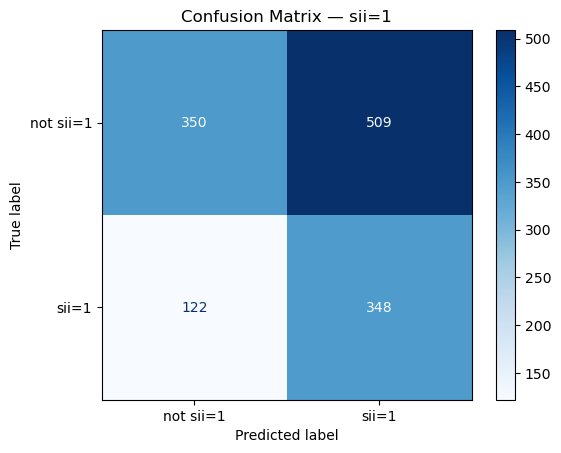

              precision    recall  f1-score   support

           0       0.74      0.41      0.53       859
           1       0.41      0.74      0.52       470

    accuracy                           0.53      1329
   macro avg       0.57      0.57      0.53      1329
weighted avg       0.62      0.53      0.53      1329



In [64]:
models[1] = train_one_step_rf(X_res, y_res, X_te, y_binary_te, step_name='sii=1')

In [65]:
y_pred_te   = models[1].predict(X_te)

step_results[1] = {
    'step_name':    'sii=1 vs [2,3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 1

print(f"\n  Assigned as sii=1 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=1 : 857 samples


## Class 2

In [66]:
# TRAIN → remove all true sii=1
mask_tr      = y_tr != 1
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES 
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

In [67]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 2')
print_dist(y_te, 'TEST  after step 2')

  Remaining train : 714
  Remaining test  : 981

--- TRAIN after step 2 ---
Class 2.0: 655 samples
Class 3.0: 59 samples
Total: 714 samples

--- TEST  after step 2 ---
Class 0.0: 552 samples
Class 1.0: 122 samples
Class 2.0: 281 samples
Class 3.0: 26 samples
Total: 981 samples


In [68]:
y_binary_tr = (y_tr == 2).astype(int)
y_binary_te = (y_te == 2).astype(int)

In [69]:
print_dist(y_binary_tr, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


--- TRAIN — binary step 3 ---
0 → 59 samples
1 → 655 samples
Total: 714 samples

--- TEST  — binary step 3 ---
0 → 700 samples
1 → 281 samples
Total: 981 samples


In [70]:
from imblearn.over_sampling import SMOTE
over_dic={0:500}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))


Resampled dataset shape Counter({1: 655, 0: 500})


In [71]:
print_dist(y_res, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


--- TRAIN — binary step 3 ---
0 → 500 samples
1 → 655 samples
Total: 1155 samples

--- TEST  — binary step 3 ---
0 → 700 samples
1 → 281 samples
Total: 981 samples



  STEP: sii=2
  Training samples : 1155
  Positive class   : 655 samples
  Negative class   : 500 samples

  Best params : {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'criterion': 'gini', 'class_weight': 'balanced'}
  Best CV F1  : 0.9501
  Test F1     : 0.1538


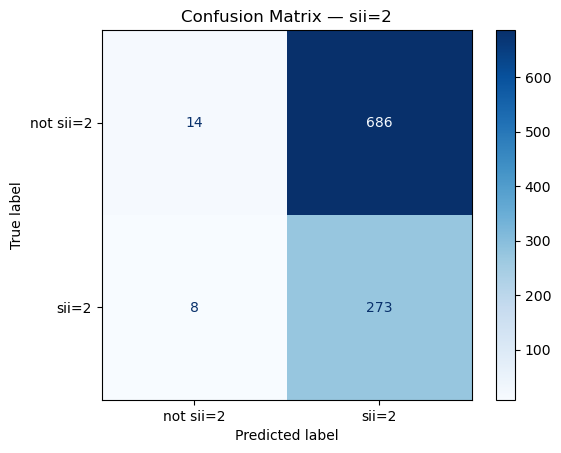

              precision    recall  f1-score   support

           0       0.64      0.02      0.04       700
           1       0.28      0.97      0.44       281

    accuracy                           0.29       981
   macro avg       0.46      0.50      0.24       981
weighted avg       0.54      0.29      0.15       981



In [73]:
models[2] = train_one_step_rf(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=2')

In [74]:
# ── Assign predictions for step 3 ────────────────────────────────────────────
y_pred_te   = models[2].predict(X_te)

step_results[2] = {
    'step_name':    'sii=2 vs [3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 2

print(f"\n  Assigned as sii=2 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=2 : 959 samples


## Class 3

In [75]:
# ── Filter for next step ──────────────────────────────────────────────────────
mask_tr      = y_tr != 2
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")

  Remaining train : 59
  Remaining test  : 708


In [76]:
y_pred_final[original_idx] = 3
step_results[3] = {
    'step_name':    'sii=3 (remaining)',
    'y_true_bin':   (y_te == 3).astype(int),
    'y_pred_bin':   np.ones(len(y_te), dtype=int),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

print(f"\n  Assigned as sii=3 : {len(original_idx)} samples (all remaining)")


  Assigned as sii=3 : 708 samples (all remaining)


## Final Result

In [77]:
# ══════════════════════════════════════════════════════════════════════════════
# REPORTE COMBINADO
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "="*75)
print("  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS")
print("="*75)

rows = []
for step, res in step_results.items():
    yt = res['y_true_bin']
    yp = res['y_pred_bin']

    # métricas binarias reales de cada paso
    prec   = precision_score(yt, yp, zero_division=0)
    rec    = recall_score(yt, yp, zero_division=0)
    f1     = f1_score(yt, yp, zero_division=0)
    n      = len(yt)
    n_pos  = yt.sum()
    tp     = ((yp == 1) & (yt == 1)).sum()
    fp     = ((yp == 1) & (yt == 0)).sum()
    fn     = ((yp == 0) & (yt == 1)).sum()

    rows.append({
        'Step':         res['step_name'],
        'N samples':    n,
        'N positive':   n_pos,
        'TP':           tp,
        'FP':           fp,
        'FN':           fn,
        'Precision':    round(prec, 4),
        'Recall':       round(rec,  4),
        'F1':           round(f1,   4),
    })

report_df = pd.DataFrame(rows)
print(report_df.to_string(index=False))


  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS
             Step  N samples  N positive   TP  FP  FN  Precision  Recall     F1
 sii=0 vs [1,2,3]       2515        1738 1186 337 552     0.7787  0.6824 0.7274
   sii=1 vs [2,3]       1329         470  348 509 122     0.4061  0.7404 0.5245
     sii=2 vs [3]        981         281  273 686   8     0.2847  0.9715 0.4403
sii=3 (remaining)        708          26   26 682   0     0.0367  1.0000 0.0708


In [78]:
# ── Multiclass final ──────────────────────────────────────────────────────────
print("\n" + "="*75)
print("  FINAL MULTICLASS REPORT (y_test vs y_pred_final)")
print("="*75)
print(classification_report(
    y_test, y_pred_final,
    target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']
))


  FINAL MULTICLASS REPORT (y_test vs y_pred_final)
              precision    recall  f1-score   support

       sii=0       1.00      0.68      0.81      1738
       sii=1       1.00      0.74      0.85       470
       sii=2       1.00      0.97      0.99       281
       sii=3       0.04      1.00      0.07        26

    accuracy                           0.73      2515
   macro avg       0.76      0.85      0.68      2515
weighted avg       0.99      0.73      0.83      2515



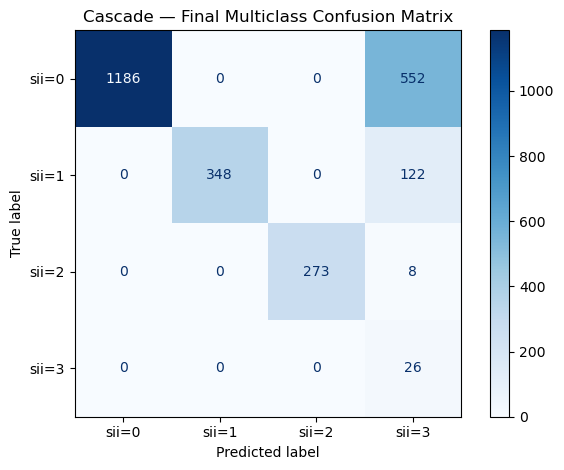

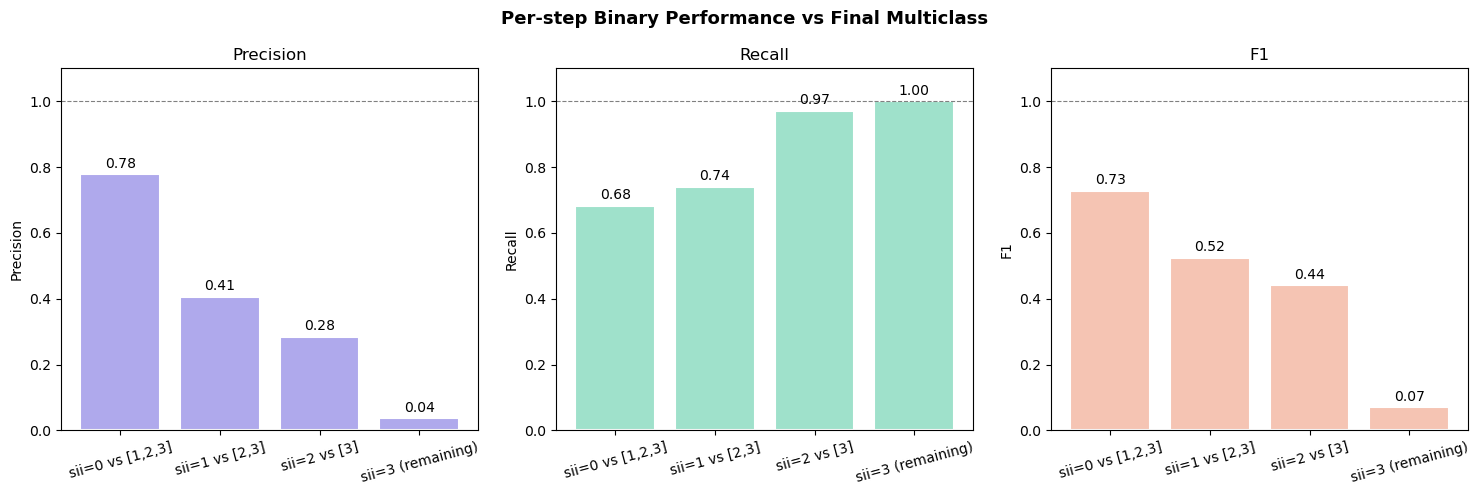

In [79]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['sii=0', 'sii=1', 'sii=2', 'sii=3']
)
disp.plot(cmap='Blues')
plt.title('Cascade — Final Multiclass Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Plot comparativo ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['Precision', 'Recall', 'F1']
colors    = ['#AFA9EC', '#9FE1CB', '#F5C4B3']

for ax, metric, color in zip(axes, metrics, colors):
    steps  = [r['Step'] for r in rows]
    values = [r[metric] for r in rows]
    bars   = ax.bar(steps, values, color=color, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=10)

plt.suptitle('Per-step Binary Performance vs Final Multiclass',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [80]:
# ── Per class summary ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  PREDICTIONS SUMMARY")
print(f"{'='*60}")
for cls in [0, 1, 2, 3]:
    true_count = (y_test == cls).sum()
    pred_count = (y_pred_final == cls).sum()
    print(f"  sii={cls} → true: {true_count:<6} predicted: {pred_count}")


  PREDICTIONS SUMMARY
  sii=0 → true: 1738   predicted: 1186
  sii=1 → true: 470    predicted: 348
  sii=2 → true: 281    predicted: 273
  sii=3 → true: 26     predicted: 708


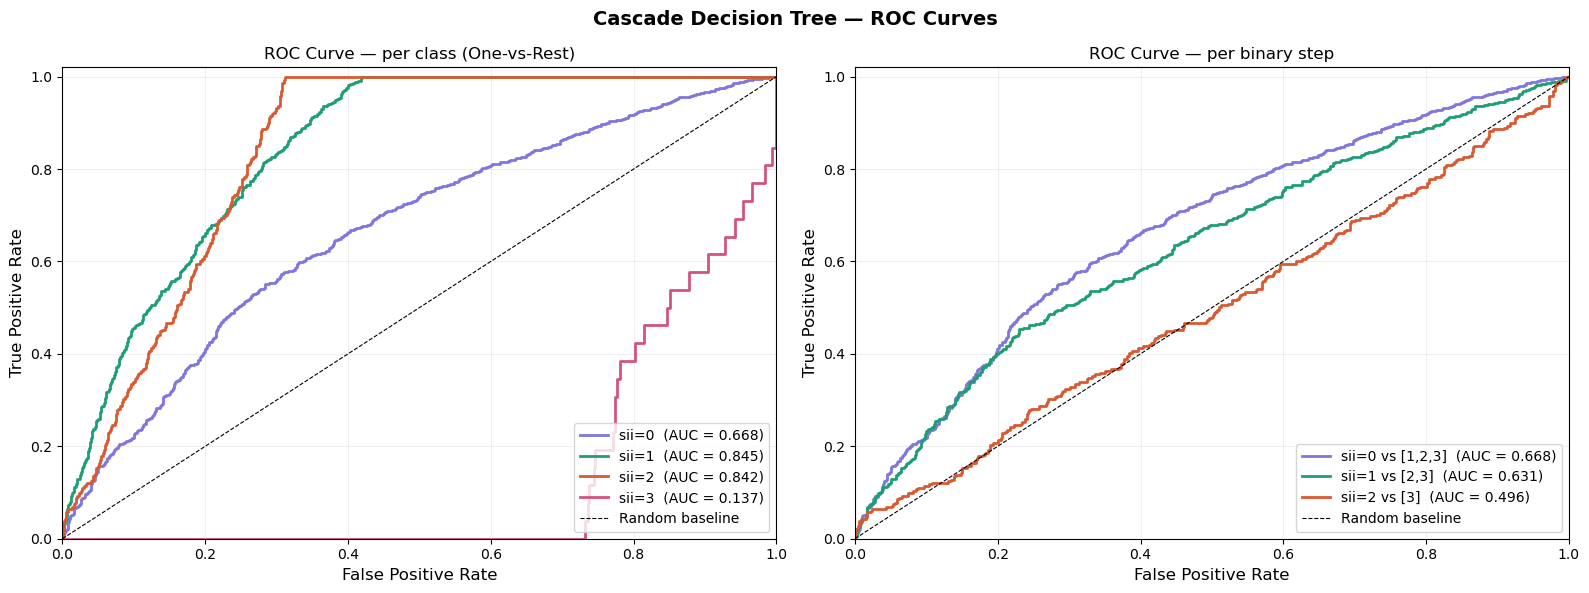


  AUC SUMMARY
  sii=0    → AUC = 0.6684
  sii=1    → AUC = 0.8451
  sii=2    → AUC = 0.8419
  sii=3    → AUC = 0.1372

  Macro AUC    : 0.6232
  Weighted AUC : 0.7153


In [ ]:
# ── 1. Collect probabilities from each step ───────────────────────────────────
# Each model gives P(class=X) for the samples it saw
# We need to reconstruct full probability matrix (n_test, 4)

n_test     = len(X_test)
proba_full = np.zeros((n_test, 4))   # one column per class

for step, res in step_results.items():
    idx    = res['original_idx']          # which original test samples this step saw
    model  = models.get(step)

    if model is not None:
        proba_step         = model.predict_proba(X_test[idx])   # shape (n_step, 2)
        proba_full[idx, step] = proba_step[:, 1]                # P(positive) for this class
    else:
        # last class — use survival probability (1 - sum of previous)
        proba_full[idx, step] = 1 - proba_full[idx, :step].sum(axis=1)

# ── 2. Binarize y_test for multiclass ROC ────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # shape (n_test, 4)

# ── 3. Compute ROC per class ──────────────────────────────────────────────────
colors     = ['#7F77DD', '#1D9E75', '#D85A30', '#D4537E']
step_names = ['sii=0', 'sii=1', 'sii=2', 'sii=3']

fpr_dict = {}
tpr_dict = {}
auc_dict = {}

for i in range(4):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], proba_full[:, i])
    auc_dict[i]                  = auc(fpr_dict[i], tpr_dict[i])

# ── 4. Plot — two panels ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1 — individual ROC per class ───────────────────────────────────────
ax = axes[0]
for i in range(4):
    ax.plot(fpr_dict[i], tpr_dict[i],
            color=colors[i],
            linewidth=2,
            label=f"{step_names[i]}  (AUC = {auc_dict[i]:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per class (One-vs-Rest)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

# ── Panel 2 — step by step binary ROC ────────────────────────────────────────
ax = axes[1]
for step, res in step_results.items():
    model = models.get(step)
    if model is None:
        continue                              # skip last class (no model)

    idx        = res['original_idx']
    y_true_bin = res['y_true_bin']
    y_proba    = model.predict_proba(X_test[idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_true_bin, y_proba)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr,
            color=colors[step],
            linewidth=2,
            label=f"{step_results[step]['step_name']}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per binary step', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

plt.suptitle('Cascade Decision Tree — ROC Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Print AUC summary ──────────────────────────────────────────────────────
print("\n" + "="*45)
print("  AUC SUMMARY")
print("="*45)
for i in range(4):
    print(f"  {step_names[i]:<8} → AUC = {auc_dict[i]:.4f}")

from sklearn.metrics import roc_auc_score
macro    = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='macro')
weighted = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='weighted')
print(f"\n  Macro AUC    : {macro:.4f}")
print(f"  Weighted AUC : {weighted:.4f}")
print("="*45)